# 02 — The Environment and the Benchmarks

**Purpose.** Define the portfolio-rebalancing problem as a Markov decision process,
*prove* that the simulator implements it correctly, and establish the bar that the
learning agent has to clear.

| | |
|---|---|
| **Inputs** | `data/processed/` (written by notebook 01) |
| **Outputs** | 8 figures (`artifacts/figures/02_*.png`), benchmark scorecards |
| **Runtime** | ≈ 1 minute on CPU |
| **Rubric** | *Problem formulation*, *correctness of implementation*, *baseline comparison* |

Two things in this notebook matter more than anything else:

1. **The golden test (§4).** A backtest that is subtly wrong almost always looks
   *better* than a correct one, because the usual mistakes — trading on
   information you would not have had, forgetting to charge costs, rebalancing
   for free — all leak profit into the result. So the environment is checked
   against wealth paths derived from first principles, not against itself.
2. **The benchmarks (§7).** Every benchmark is executed through the *same*
   environment as the agent, so it pays the same transaction costs at the same
   weekly frequency. A benchmark evaluated outside the simulator trades for free,
   and beating it would prove nothing.

## 1 Setup

In [1]:
import dataclasses
import shutil
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from gymnasium.utils.env_checker import check_env
from IPython.display import Image, display

from portfoliorl import benchmarks, config, env, features, metrics, plots, utils

warnings.filterwarnings("ignore", category=UserWarning, module="gymnasium")

utils.set_global_seed(0)
plots.apply_style()
config.ensure_dirs()

CFG = config.DEFAULT
ds = features.load_dataset()

test = ds.split("test")
train = ds.split("train")

print(f"full sample : {ds.dates[0].date()} -> {ds.dates[-1].date()}  ({len(ds.dates):,} days)")
print(f"train       : {train.dates[0].date()} -> {train.dates[-1].date()}  ({len(train.dates):,} days)")
print(f"test        : {test.dates[0].date()} -> {test.dates[-1].date()}  ({len(test.dates):,} days)")
print(f"observation : {ds.obs_dim} dimensions  ({ds.n_market_features} market + 8 portfolio)")

full sample : 2005-09-06 -> 2025-12-31  (5,113 days)
train       : 2005-09-06 -> 2017-12-29  (3,102 days)
test        : 2021-01-04 -> 2025-12-31  (1,255 days)
observation : 31 dimensions  (23 market + 8 portfolio)


## 2 The problem as a Markov decision process

Portfolio rebalancing maps onto the standard RL loop almost directly. Every week
the agent observes the state of the market and of its own portfolio, picks one of
six model allocations, and receives a reward reflecting how much wealth it gained
and how much risk it took to get there.

$$\mathcal{M} = \langle \mathcal{S}, \mathcal{A}, P, R, \gamma \rangle$$

The one non-obvious modelling choice is the **separation of decision frequency
from accounting frequency**. The agent acts once per week
($\texttt{steps\_per\_decision} = 5$), but wealth compounds *daily* inside each
step. This matters because:

* rebalancing daily would multiply transaction costs by five for almost no extra
  information — the features (63-day momentum, 20-day volatility) simply do not
  move fast enough to justify it;
* but measuring risk on weekly returns would discard exactly the intra-week
  volatility that drawdown-aware investors care about.

So one environment step advances five trading days, and the daily return series
it produces is what every Sharpe ratio and drawdown in this project is computed
from.

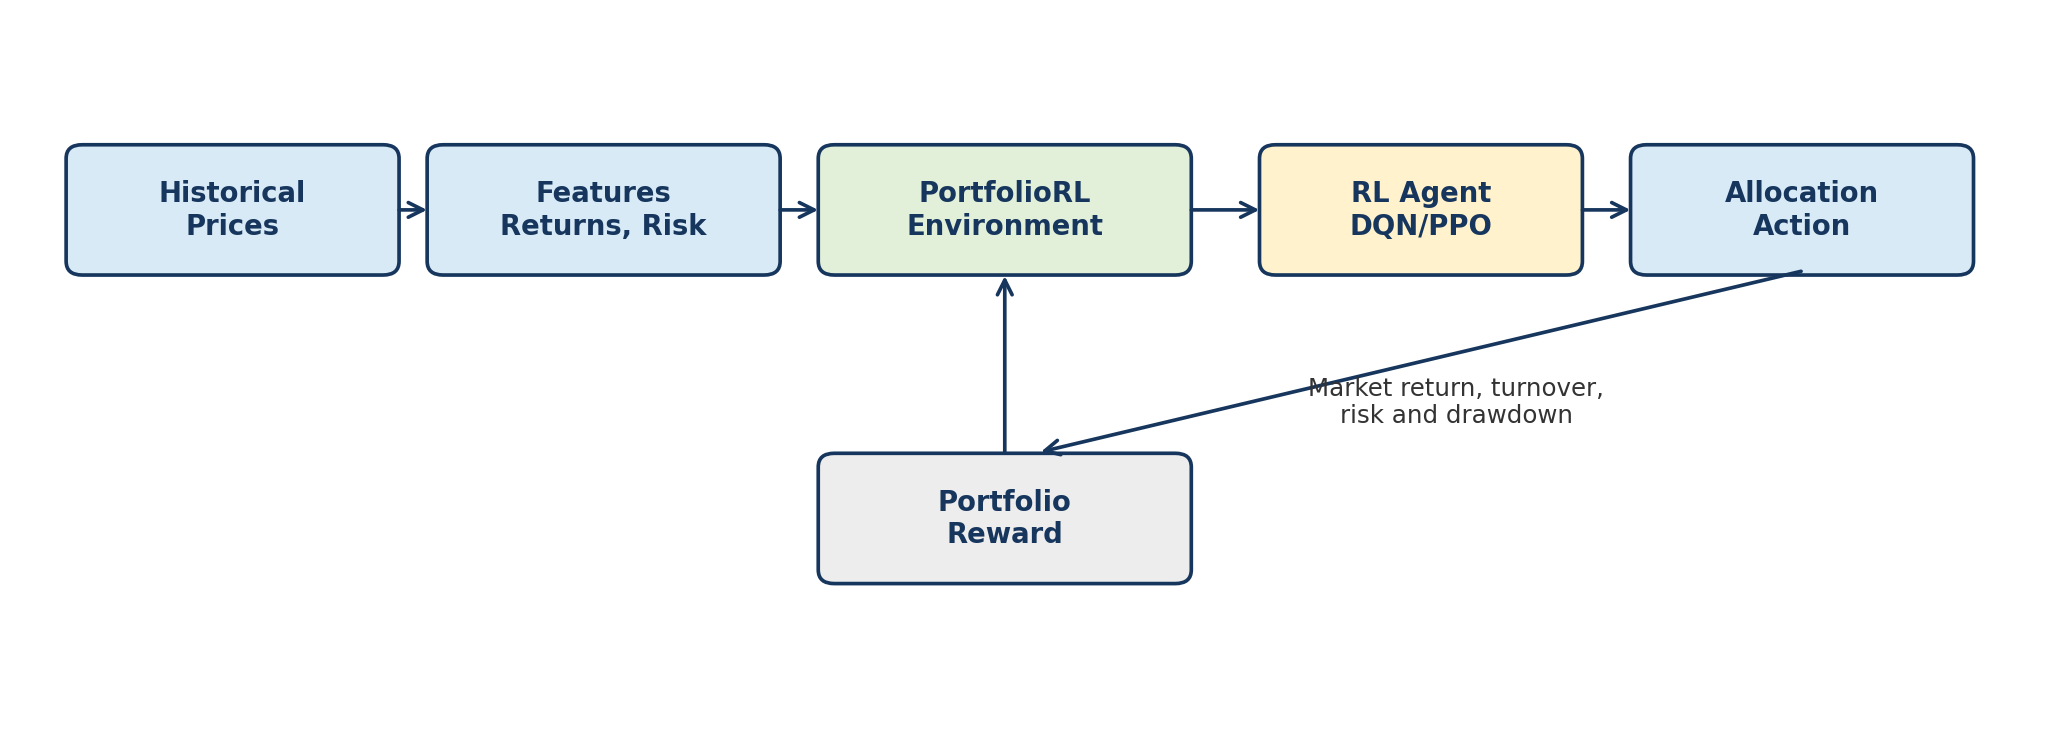

Figure 2.1 -> artifacts\figures\02_01_mdp_loop.png


In [2]:
# Figure 2.1 -- the agent/environment loop, reproduced from the design document
# so the notebook is self-contained.
src = config.PROJECT_ROOT / "Docs" / "rl_loop_diagram.png"
dst = config.ARTIFACTS_FIGURES / "02_01_mdp_loop.png"
if src.exists():
    shutil.copyfile(src, dst)
    display(Image(filename=str(dst), width=680))
    print(f"Figure 2.1 -> {dst.relative_to(config.PROJECT_ROOT)}")
else:
    print("Diagram not found; see Docs/ for the design document.")

### 2.1 Action space $\mathcal{A}$

Six discrete allocations rather than a continuous simplex. This is a deliberate
restriction, and it is the reason a *value-based* method such as DQN is
applicable at all:

* **Tractability.** A continuous weight vector would require a policy-gradient
  or actor–critic method; with six actions, $Q(s, \cdot)$ is a six-vector and
  the greedy policy is an `argmax`.
* **Realism.** Institutional mandates genuinely are expressed as a small menu of
  model portfolios, not as an unconstrained optimiser output.
* **Interpretability.** "The agent moved to the bond-heavy sleeve in March 2020"
  is a statement a human can audit. "The agent set $w_{\text{TLT}} = 0.5834$" is
  not.

The allocations are ordered from defensive to aggressive, which also makes the
action-frequency charts in notebook 05 readable as a risk dial.

In [3]:
action_table = pd.DataFrame(
    np.asarray(config.ACTION_ALLOCATIONS),
    columns=list(CFG.data.tickers),
    index=pd.Index(range(len(config.ACTION_LABELS)), name="Action"),
)
action_table.insert(0, "Label", list(config.ACTION_LABELS))
action_table["Equity %"] = action_table["SPY"]

display(
    action_table.style.format({t: "{:.0%}" for t in CFG.data.tickers} | {"Equity %": "{:.0%}"})
    .background_gradient(cmap="RdYlGn_r", subset=["Equity %"])
    .set_caption("Table 2.1 — the six model allocations, ordered defensive to aggressive")
)

,Label,SPY,TLT,GLD,SHY,Equity %
Action,,,,,,
0,Cash (100% SHY),0%,0%,0%,100%,0%
1,Balanced 60/40,60%,40%,0%,0%,60%
2,Diversified 40/40/20,40%,40%,20%,0%,40%
3,Equity-heavy 80/20,80%,20%,0%,0%,80%
4,Equal weight,25%,25%,25%,25%,25%
5,Bond-heavy 20/60/20,20%,60%,20%,0%,20%


### 2.2 State space $\mathcal{S}$

The observation has 31 dimensions: 23 describing the market and 8 describing the
agent's own position.

The eight portfolio features are not padding — they are what makes the problem
**Markov**. Two things depend on history rather than on today's prices:

* **Transaction costs** depend on the *current* weights, because turnover is
  measured against them. Without the weights in the state, the agent cannot know
  what a switch would cost.
* **The drawdown penalty** depends on the running peak. Without drawdown depth
  and duration in the state, the reward would appear stochastic to the agent for
  reasons it cannot observe — the classic partial-observability failure.

Every market feature is lagged by one day (`.shift(1)`), which is the causality
guarantee demonstrated in notebook 01, Figure 1.12.

In [4]:
market = features.describe_features(list(ds.features.columns))
portfolio_state = pd.DataFrame(
    {
        "feature": [f"w_{t}" for t in CFG.data.tickers]
        + ["portfolio_vol", "drawdown", "dd_duration", "progress"],
        "description": [f"Current weight in {t}" for t in CFG.data.tickers]
        + [
            "20-day realised volatility of the portfolio itself (x100)",
            "Fractional distance below the running peak",
            "Years spent continuously below that peak (capped at 3)",
            "Fraction of the episode elapsed",
        ],
    }
)

print(f"Market features   : {len(market):>2}")
print(f"Portfolio features: {len(portfolio_state):>2}")
print(f"Observation vector: {ds.obs_dim}")
display(portfolio_state.style.hide(axis="index").set_caption(
    "Table 2.2 — the eight portfolio-state features that keep the MDP Markov"
))

Market features   : 23
Portfolio features:  8
Observation vector: 31


feature,description
w_SPY,Current weight in SPY
w_TLT,Current weight in TLT
w_GLD,Current weight in GLD
w_SHY,Current weight in SHY
portfolio_vol,20-day realised volatility of the portfolio itself (x100)
drawdown,Fractional distance below the running peak
dd_duration,Years spent continuously below that peak (capped at 3)
progress,Fraction of the episode elapsed


### 2.3 Reward function $R$

$$
r_t \;=\; 100 \times \Big[\underbrace{\log(1 + r^{\text{net}}_t)}_{\text{growth}}
\;-\; \underbrace{\lambda_1 \, \tau_t}_{\text{trading}}
\;-\; \underbrace{\lambda_2 \, \sigma_t}_{\text{volatility}}
\;-\; \underbrace{\lambda_3 \max(0, \Delta D_t)}_{\text{new drawdown}}\Big]
$$

Four design choices, each of which is tested in §4–§5:

**Log returns, not simple returns.** Because $\log$ is additive,
$\sum_t \log(1 + r_t) = \log(W_T / W_0)$ *exactly*. With $\gamma \to 1$ and the
penalties switched off, maximising undiscounted episode return is therefore
mathematically identical to maximising terminal wealth — the RL objective *is*
the investment objective, not a proxy for it. Simple returns would make the
agent maximise the arithmetic mean, which systematically overstates compounded
growth (Jensen's inequality) and quietly rewards volatility.

**Costs enter twice.** $r^{\text{net}}$ is already net of the fee, so the agent
loses real wealth when it trades; $\lambda_1 \tau_t$ is an *additional*
behavioural penalty representing slippage and market impact that a flat
commission understates. At $\lambda_1 = 0.002$ the extra charge is 20 bps per
unit of turnover, roughly four times the modelled commission.

**Volatility uses the portfolio's own realised $\sigma$, daily and not
annualised.** Annualising would multiply it by $\sqrt{252} \approx 15.9$ and
swamp the growth term.

**Drawdown penalises the *increment*, not the level.** Penalising the level
would charge the agent repeatedly for a loss it already took and cannot undo,
which biases it toward risk-seeking behaviour to escape the penalty. Charging
only $\max(0, \Delta D_t)$ prices *new* damage.

The $\lambda$ values are calibrated in §5.1 so that no single term dominates.

In [5]:
reward_cfg = pd.DataFrame(
    [
        ["reward_scale", CFG.env.reward_scale, "Rescales O(1e-3) weekly log returns into O(0.1) rewards"],
        ["lambda_turnover", CFG.env.lambda_turnover, "Extra 20 bps per unit turnover (slippage / impact)"],
        ["lambda_volatility", CFG.env.lambda_volatility, "Applied to daily portfolio sigma, not annualised"],
        ["lambda_drawdown", CFG.env.lambda_drawdown, "Applied to the drawdown increment only"],
        ["transaction_cost_bps", CFG.env.transaction_cost_bps, "Round-trip commission deducted from wealth"],
        ["steps_per_decision", CFG.env.steps_per_decision, "Trading days advanced per action (weekly)"],
    ],
    columns=["Parameter", "Value", "Rationale"],
)
display(reward_cfg.style.hide(axis="index").format({"Value": "{:g}"}).set_caption(
    "Table 2.3 — reward and cost parameters"
))

Parameter,Value,Rationale
reward_scale,100,Rescales O(1e-3) weekly log returns into O(0.1) rewards
lambda_turnover,0.002,Extra 20 bps per unit turnover (slippage / impact)
lambda_volatility,0.1,"Applied to daily portfolio sigma, not annualised"
lambda_drawdown,0.5,Applied to the drawdown increment only
transaction_cost_bps,5,Round-trip commission deducted from wealth
steps_per_decision,5,Trading days advanced per action (weekly)


## 3 Does it behave like a Gymnasium environment?

`check_env` is the cheap, mechanical check: correct `step` signature, seeding
that actually reproduces, observations inside the declared space. It catches
interface bugs, not accounting bugs — §4 handles those.

In [6]:
e = env.PortfolioEnv(train, mode="train")
check_env(e, skip_render_check=True)

print("check_env passed")
print(f"  action space      : {e.action_space}")
print(f"  observation space : {e.observation_space}")
print(f"  decisions/episode : {e.n_decisions} weeks ({e.n_decisions * CFG.env.steps_per_decision} trading days)")

check_env passed
  action space      : Discrete(6)
  observation space : Box(-10.0, 10.0, (31,), float32)
  decisions/episode : 52 weeks (260 trading days)


### 3.1 One step, traced by hand

The clearest way to show what a step does is to print everything it returns. The
trace below starts from 100% cash (`initial_action = 0`) and switches to the
equity-heavy sleeve, so the first decision pays a real entry cost.

In [7]:
e = env.PortfolioEnv(test, mode="eval")
obs, info = e.reset(seed=0)
print(f"reset -> start {info['start_date'].date()}, weights {np.round(obs[-8:-4], 3)}\n")

for step, action in enumerate([3, 3, 0], start=1):
    obs, reward, terminated, truncated, info = e.step(action)
    print(f"--- step {step}: action {action} ({config.ACTION_LABELS[action]}) ---")
    print(f"  week ending      {info['date'].date()}")
    print(f"  turnover         {info['turnover']:.4f}   cost {info['cost_fraction'] * 1e4:.2f} bps")
    print(f"  net return       {info['net_return']:+.4%}   wealth ${info['wealth']:,.2f}")
    print(f"  drawdown         {info['drawdown']:.4%}   portfolio sigma {info['portfolio_vol']:.4%}/day")
    print(f"  reward           {reward:+.4f}"
          f"  = {info['reward_return']:+.4f} (growth)"
          f" {info['reward_turnover_penalty']:+.4f} (trade)"
          f" {info['reward_vol_penalty']:+.4f} (vol)"
          f" {info['reward_dd_penalty']:+.4f} (dd)")
    print(f"  terminated={terminated}  truncated={truncated}\n")

reset -> start 2021-01-04, weights [0. 0. 0. 1.]

--- step 1: action 3 (Equity-heavy 80/20) ---
  week ending      2021-01-11
  turnover         1.0000   cost 10.00 bps
  net return       +1.2248%   wealth $101,224.85
  drawdown         0.5782%   portfolio sigma 0.5845%/day
  reward           +0.6699  = +1.2174 (growth) -0.2000 (trade) -0.0584 (vol) -0.2891 (dd)
  terminated=False  truncated=False

--- step 2: action 3 (Equity-heavy 80/20) ---
  week ending      2021-01-19
  turnover         0.0107   cost 0.11 bps
  net return       +0.1546%   wealth $101,381.38
  drawdown         0.4244%   portfolio sigma 0.5418%/day
  reward           +0.0982  = +0.1545 (growth) -0.0021 (trade) -0.0542 (vol) -0.0000 (dd)
  terminated=False  truncated=False

--- step 3: action 0 (Cash (100% SHY)) ---
  week ending      2021-01-26
  turnover         1.0000   cost 10.00 bps
  net return       -0.1000%   wealth $101,280.00
  drawdown         0.5240%   portfolio sigma 0.4405%/day
  reward           -0.393

Note `terminated=False` throughout. Reaching the end of the data is a **time
limit**, not a terminal state — the world does not stop, we simply run out of
history. Reporting it as termination would tell the learner that
$V(s_{T}) = 0$, so it would learn that the end of the sample is worthless and
distort the value estimates near it. Gymnasium's `truncated` flag exists exactly
for this, and the training loop bootstraps through it.

## 4 Correctness: weight drift and the golden tests

### 4.1 Weights drift between rebalances

This is the most commonly mis-implemented part of a rebalancing backtest.
Between decisions the agent does *nothing*, but its weights change anyway
because the assets move at different rates:

$$w_{i,t+1} = \frac{w_{i,t}(1 + r_{i,t+1})}{\sum_j w_{j,t}(1 + r_{j,t+1})}$$

Turnover must therefore be measured against the **drifted** weights, not against
the previous target:

$$\tau_t = \tfrac{1}{2} \sum_i \big| w^{\text{target}}_{i,t} - w^{\text{drifted}}_{i,t} \big|$$

If it were measured target-to-target, holding a constant allocation would show
zero turnover and cost nothing — yet in reality maintaining a fixed 60/40 mix
requires selling the winner and buying the loser every single week. That error
makes every static benchmark look free and is precisely the kind of bug that
flatters a backtest.

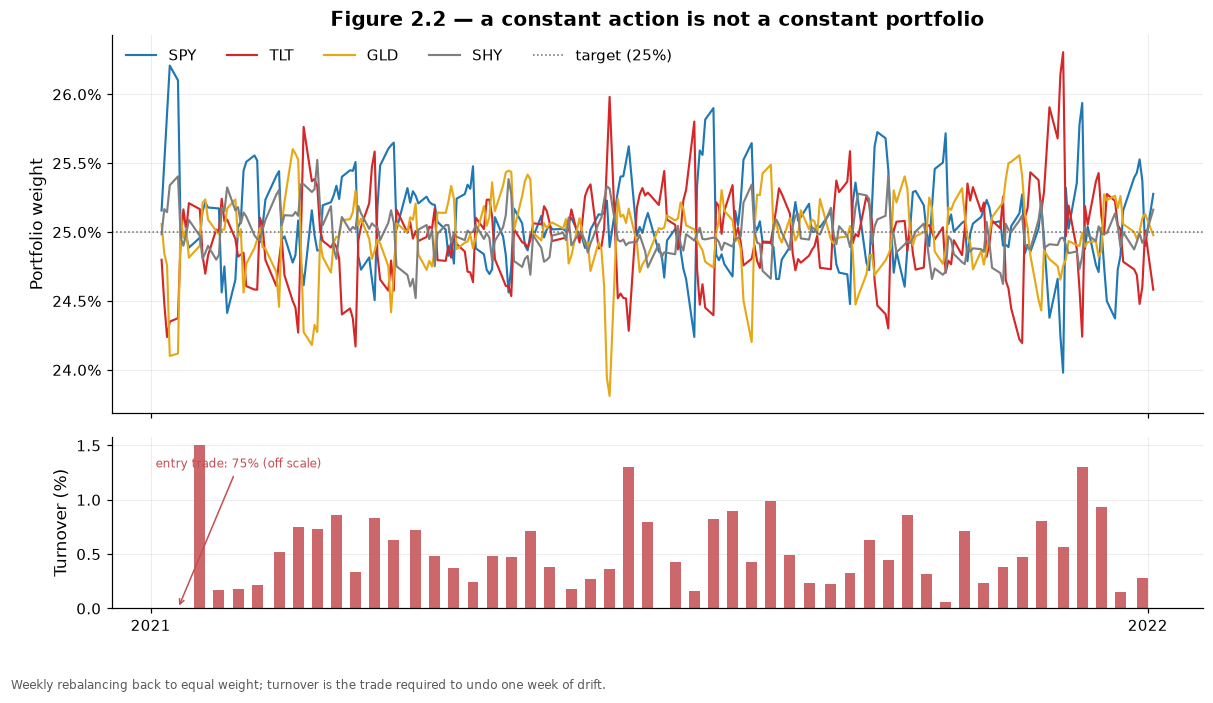

Weeks with zero turnover after entry: 0 of 49
Median weekly turnover: 0.475%   annualised: 0.27x


In [8]:
# Figure 2.2 -- one year of holding action 4 (equal weight) without any change of mind.
daily_ew, sum_ew = env.run_policy(test, benchmarks.constant_action(4))
window = daily_ew.iloc[:252]
weight_cols = [f"w_{t}" for t in CFG.data.tickers]

fig, (ax, ax2) = plt.subplots(
    2, 1, figsize=(11, 6), sharex=True, gridspec_kw={"height_ratios": [2.2, 1]}
)

for ticker in CFG.data.tickers:
    ax.plot(window.index, window[f"w_{ticker}"], color=plots.ASSET_COLORS[ticker], lw=1.4, label=ticker)
ax.axhline(0.25, color="0.4", ls=":", lw=1, label="target (25%)")
ax.set_ylabel("Portfolio weight")
ax.set_title("Figure 2.2 — a constant action is not a constant portfolio")
ax.legend(ncol=5, loc="upper left")
plots.format_pct_axis(ax, decimals=1)

turn = sum_ew["decisions"].loc[window.index[0] : window.index[-1], "turnover"]
# The entry trade (moving out of the starting cash position) is plotted separately
# because at ~75% it is two orders of magnitude larger than the weekly drift
# corrections and would flatten them into invisibility.
ax2.bar(turn.index[1:], turn.to_numpy()[1:] * 1e2, width=4, color="#c44e52", alpha=0.85)
ax2.set_ylabel("Turnover (%)")
ax2.set_xlabel("")
ax2.annotate(
    f"entry trade: {turn.iloc[0]:.0%} (off scale)",
    xy=(turn.index[0], 0), xytext=(0.04, 0.82), textcoords="axes fraction",
    fontsize=8, color="#c44e52",
    arrowprops=dict(arrowstyle="->", color="#c44e52", lw=1),
)
plots.tidy_dates(ax2, interval=1)

plots.caption(fig, "Weekly rebalancing back to equal weight; turnover is the trade required to undo one week of drift.")
fig.tight_layout()
plots.save_fig(fig, "02_02_weight_drift")
plt.show()

print(f"Weeks with zero turnover after entry: {(turn.iloc[1:] < 1e-12).sum()} of {len(turn) - 1}")
print(f"Median weekly turnover: {turn.iloc[1:].median():.3%}   annualised: {turn.iloc[1:].sum():.2f}x")

**What this shows.** The weights fan out between Wednesdays and are pulled back
every week; the lower panel is the trade needed to do it. Turnover is never zero
after the first week, so holding a "static" allocation genuinely costs money —
which is exactly what the environment charges for.

### 4.2 Golden test — the simulator against first principles

Two wealth paths are derived here **without using the environment's arithmetic**,
and then compared to what the environment produces.

**Test A — single asset, closed form.** The episode starts in 100% SHY and the
policy keeps choosing it, so turnover is exactly zero after entry and the answer
collapses to a ratio of two prices:

$$W_T = W_0 \cdot \frac{P^{\text{SHY}}_T}{P^{\text{SHY}}_0}$$

**Test B — buy and hold, by share accounting.** Buy $N_i = w_i W / P_{i,0}$
shares once, never trade again, and mark to market:

$$W_t = \sum_i N_i P_{i,t}$$

This is a completely different formulation from the environment's weight-drift
recursion, so agreement to machine precision means the drift formula, the daily
compounding and the cost deduction are all simultaneously correct. To make the
environment produce a genuine buy-and-hold path, one decision is stretched over
the whole test window.

In [9]:
# --- Test A: 100% SHY, closed form ---------------------------------------- #
daily_a, sum_a = env.run_policy(test, benchmarks.constant_action(0))
shy = test.prices["SHY"]
p0 = shy.loc[: daily_a.index[0]].iloc[-2]          # the day before the first recorded day
reference_a = CFG.env.initial_value * shy.loc[daily_a.index] / p0

# --- Test B: equal-weight buy & hold, share accounting --------------------- #
cfg_hold = dataclasses.replace(
    CFG.env, steps_per_decision=len(test.prices) - 1, episode_length=1
)
daily_b, sum_b = env.run_policy(test, benchmarks.constant_action(4), env_cfg=cfg_hold)
ref_frame, ref_sum = benchmarks.buy_and_hold(test, np.asarray(config.ACTION_ALLOCATIONS[4]))
common = daily_b.index.intersection(ref_frame.index)
reference_b = ref_frame.loc[common, "wealth"]

err_a = (daily_a["wealth"] / reference_a - 1.0).abs()
err_b = (daily_b.loc[common, "wealth"] / reference_b - 1.0).abs()

print(f"Test A  env ${sum_a['final_wealth']:,.6f}   closed form ${reference_a.iloc[-1]:,.6f}"
      f"   max relative error {err_a.max():.2e}")
print(f"Test B  env ${daily_b.loc[common[-1], 'wealth']:,.6f}   share accounting ${reference_b.iloc[-1]:,.6f}"
      f"   max relative error {err_b.max():.2e}")

Test A  env $108,397.093486   closed form $108,397.093486   max relative error 2.89e-14
Test B  env $147,024.791216   share accounting $147,024.791216   max relative error 8.88e-15


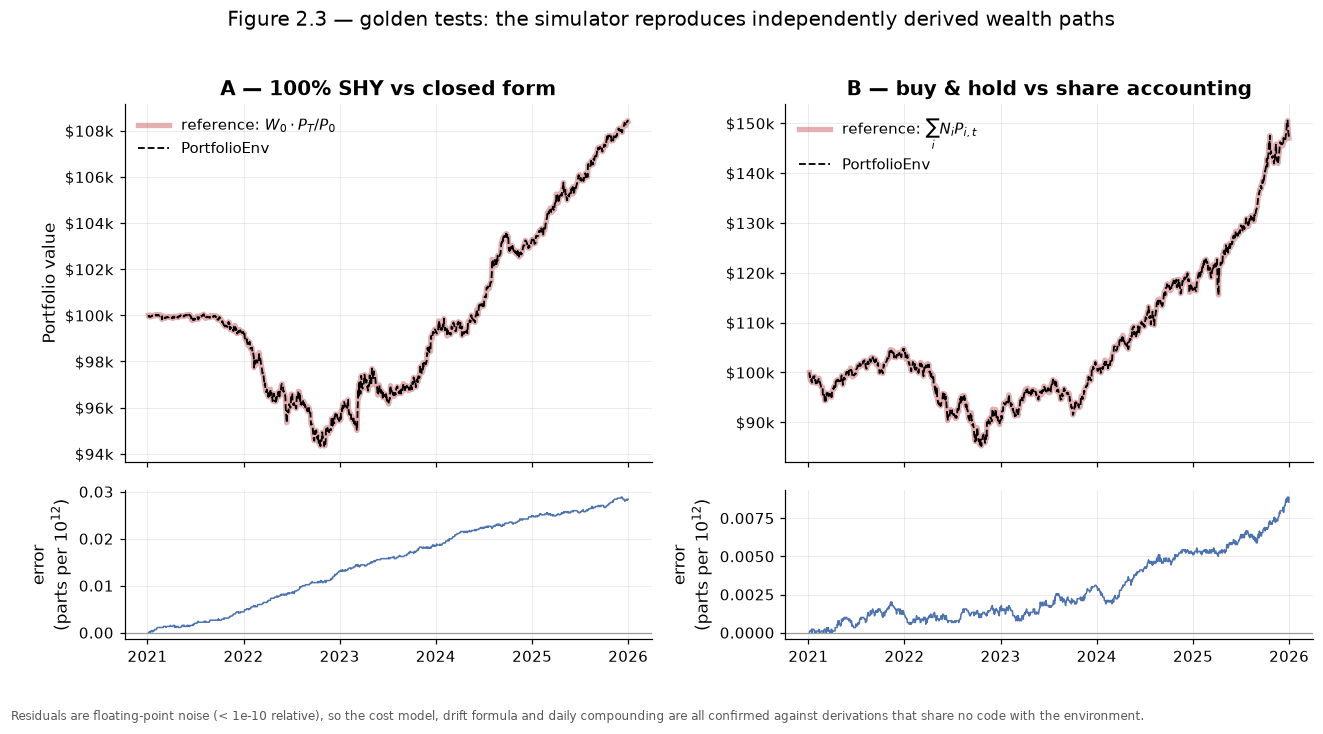

In [10]:
# Figure 2.3 -- the two golden tests, with their residuals.
fig, axes = plt.subplots(
    2, 2, figsize=(12, 6), sharex="col", gridspec_kw={"height_ratios": [2.4, 1]}
)

panels = [
    (axes[0, 0], axes[1, 0], daily_a["wealth"], reference_a, err_a,
     "A — 100% SHY vs closed form", "$W_0 \\cdot P_T / P_0$"),
    (axes[0, 1], axes[1, 1], daily_b.loc[common, "wealth"], reference_b, err_b,
     "B — buy & hold vs share accounting", "$\\sum_i N_i P_{i,t}$"),
]

for ax, ax_err, env_path, ref_path, err, title, ref_label in panels:
    ax.plot(ref_path.index, ref_path, color="#c44e52", lw=3.5, alpha=0.45, label=f"reference: {ref_label}")
    ax.plot(env_path.index, env_path, color="black", lw=1.2, ls="--", label="PortfolioEnv")
    ax.set_title(title)
    ax.legend(loc="upper left")
    plots.format_money_axis(ax)

    ax_err.plot(err.index, err.to_numpy() * 1e12, color="#4c72b0", lw=1)
    ax_err.set_ylabel("error\n(parts per $10^{12}$)")
    ax_err.axhline(0, color="0.6", lw=0.8)
    plots.tidy_dates(ax_err, interval=1)

axes[0, 0].set_ylabel("Portfolio value")
fig.suptitle("Figure 2.3 — golden tests: the simulator reproduces independently derived wealth paths", y=1.02)
plots.caption(
    fig,
    "Residuals are floating-point noise (< 1e-10 relative), so the cost model, drift formula and daily "
    "compounding are all confirmed against derivations that share no code with the environment.",
)
fig.tight_layout()
plots.save_fig(fig, "02_03_golden_test")
plt.show()

**What this shows.** The dashed simulator path sits inside the thick reference
line at every point, and the residual panels are flat at the scale of $10^{-12}$
— pure floating-point noise. This is the strongest single piece of correctness
evidence in the project, and it is enforced permanently by
`tests/test_env.py::test_golden_single_asset_matches_closed_form` and
`::test_golden_buy_and_hold_matches_share_accounting`.

## 5 The reward, decomposed

### 5.1 The return term sums to terminal log wealth

The additivity claim from §2.3 is not a metaphor — it is checkable. With all
three $\lambda$ set to zero, the total episode reward divided by the scale
should equal $\log(W_T / W_0)$ to machine precision.

In [11]:
cfg_plain = dataclasses.replace(
    CFG.env, lambda_turnover=0.0, lambda_volatility=0.0, lambda_drawdown=0.0
)
_, sum_plain = env.run_policy(test, benchmarks.constant_action(1), env_cfg=cfg_plain)

lhs = sum_plain["total_reward"] / CFG.env.reward_scale
rhs = np.log(sum_plain["final_wealth"] / CFG.env.initial_value)
print(f"sum(reward) / scale = {lhs:.12f}")
print(f"log(W_T / W_0)      = {rhs:.12f}")
print(f"difference          = {abs(lhs - rhs):.2e}")

sum(reward) / scale = 0.261512116875
log(W_T / W_0)      = 0.261512116875
difference          = 5.00e-16


### 5.2 Are the penalties calibrated, or is one of them shouting?

A penalty an order of magnitude larger than the growth term does not express a
preference — it overrides the objective entirely. With $\lambda_1 = 0.5$ (the
first value tried), a single 100%-turnover switch would have cost 50 reward units
against a weekly growth term of roughly 0.15: the agent would have learned to sit
in cash forever and never discover anything about markets. The table below is the
sanity check that keeps the terms comparable.

In [12]:
_, sum_bal = env.run_policy(test, benchmarks.constant_action(2))
dec = sum_bal["decisions"]

terms = pd.DataFrame(
    {
        "Median |value|": [
            dec["reward_return"].abs().median(),
            dec["reward_turnover_penalty"].abs().median(),
            dec["reward_vol_penalty"].abs().median(),
            dec["reward_dd_penalty"].abs().median(),
        ],
        "Max |value|": [
            dec["reward_return"].abs().max(),
            dec["reward_turnover_penalty"].abs().max(),
            dec["reward_vol_penalty"].abs().max(),
            dec["reward_dd_penalty"].abs().max(),
        ],
    },
    index=["Growth", "Turnover penalty", "Volatility penalty", "Drawdown penalty"],
)
terms["Share of median |growth|"] = terms["Median |value|"] / terms.loc["Growth", "Median |value|"]

display(
    terms.style.format({"Median |value|": "{:.4f}", "Max |value|": "{:.4f}",
                        "Share of median |growth|": "{:.1%}"})
    .set_caption("Table 2.4 — reward term magnitudes (diversified 40/40/20 allocation, test split)")
)

,Median |value|,Max |value|,Share of median |growth|
Growth,0.9398,7.0774,100.0%
Turnover penalty,0.0011,0.2000,0.1%
Volatility penalty,0.0586,0.1686,6.2%
Drawdown penalty,0.0000,3.3916,0.0%


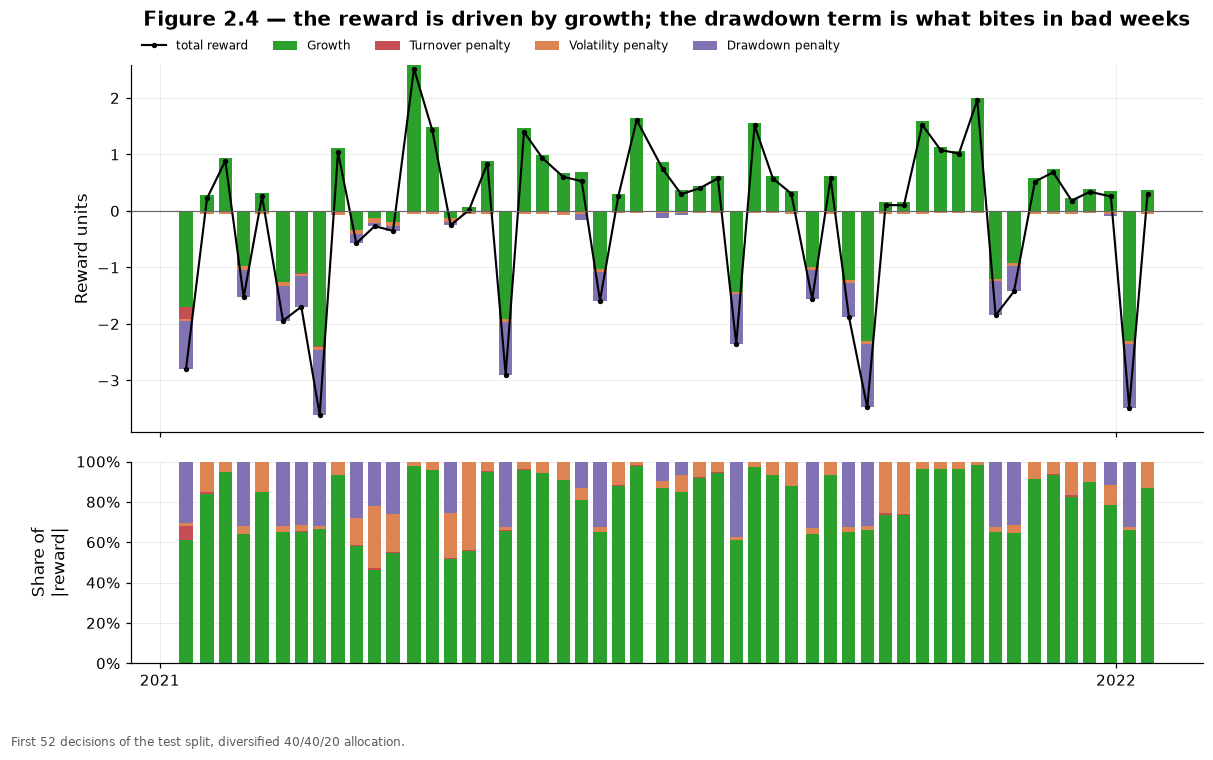

In [13]:
# Figure 2.4 -- how the four terms combine, week by week.
weeks = dec.iloc[:52]
fig, (ax, ax2) = plt.subplots(2, 1, figsize=(11, 6.5), sharex=True,
                              gridspec_kw={"height_ratios": [2, 1.1]})

components = {
    "Growth": ("reward_return", "#2ca02c"),
    "Turnover penalty": ("reward_turnover_penalty", "#c44e52"),
    "Volatility penalty": ("reward_vol_penalty", "#dd8452"),
    "Drawdown penalty": ("reward_dd_penalty", "#8172b3"),
}
pos = np.zeros(len(weeks))
neg = np.zeros(len(weeks))
for label, (col, colour) in components.items():
    values = weeks[col].to_numpy()
    base = np.where(values >= 0, pos, neg)
    ax.bar(weeks.index, values, bottom=base, width=5, color=colour, label=label)
    pos = pos + np.where(values >= 0, values, 0.0)
    neg = neg + np.where(values < 0, values, 0.0)

ax.plot(weeks.index, weeks["reward"], color="black", lw=1.4, marker="o", ms=2.5, label="total reward")
ax.axhline(0, color="0.4", lw=0.8)
ax.set_ylabel("Reward units")
ax.set_title("Figure 2.4 — the reward is driven by growth; the drawdown term is what bites in bad weeks", pad=26)
ax.legend(ncol=5, loc="lower left", bbox_to_anchor=(0, 1.005), fontsize=8, frameon=False)

share = weeks[[c for c, _ in components.values()]].abs()
share = share.div(share.sum(axis=1), axis=0)
bottom = np.zeros(len(weeks))
for label, (col, colour) in components.items():
    ax2.bar(weeks.index, share[col], bottom=bottom, width=5, color=colour)
    bottom = bottom + share[col].to_numpy()
ax2.set_ylabel("Share of\n|reward|")
ax2.set_ylim(0, 1)
plots.format_pct_axis(ax2)
plots.tidy_dates(ax2, interval=1)

plots.caption(fig, "First 52 decisions of the test split, diversified 40/40/20 allocation.")
fig.tight_layout()
plots.save_fig(fig, "02_04_reward_decomposition")
plt.show()

**What this shows.** Growth (green) sets the sign of the reward in every week —
the agent is paid to compound wealth, not to avoid risk. The turnover penalty is
almost invisible here because holding one allocation barely trades; it only
matters for a policy that switches. The drawdown penalty is the one with real
teeth: in weeks that dig a *new* low it adds roughly a third again to the loss,
which is exactly the asymmetry an investor feels. Note that recovering weeks
carry no drawdown penalty at all — the agent is charged for causing damage, not
for being underwater.

## 6 Training episodes: random starts

Training on the full 2005–2017 history as a single episode would give the agent
one trajectory to replay thousands of times — a recipe for memorising the 2008
crash rather than learning a policy. Instead each training episode samples a
random start date and runs for 52 weekly decisions.

This buys three things:

* **Decorrelated updates.** Consecutive episodes visit different market regimes,
  so the replay buffer is not dominated by one stretch of history.
* **A meaningful discount horizon.** With $\gamma = 0.99$ and 52 steps, the
  effective horizon $1/(1-\gamma) = 100$ comfortably spans the episode, so the
  agent optimises the whole year rather than the next few weeks.
* **Exposure to every regime, repeatedly.** Bull, bear and sideways starts all
  appear many times across 120,000 training steps.

Evaluation never does this: it is always a single deterministic pass over the
whole split, so results are reproducible and comparable across strategies.

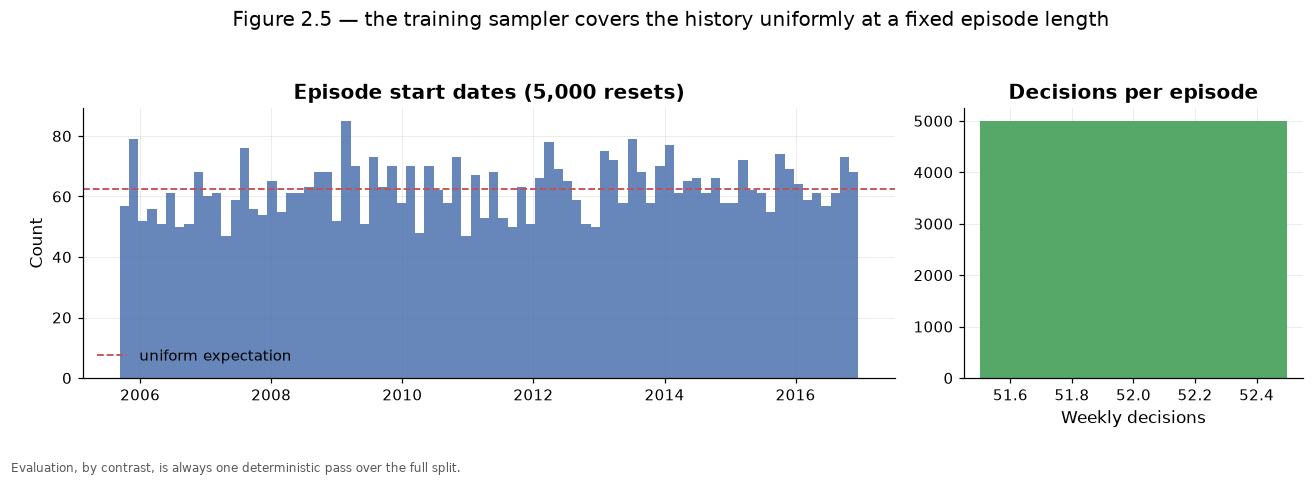

Distinct start dates : 2,360 of 5,000 resets
Episode length       : {52} decisions  (configured: 52)
Earliest / latest    : 2005-09-09 / 2016-12-16


In [14]:
# Figure 2.5 -- 5,000 resets of the training sampler.
sampler = env.PortfolioEnv(train, mode="train")
starts, lengths = [], []
for seed in range(5000):
    _, info = sampler.reset(seed=seed)
    starts.append(info["start_date"])
    steps = 0
    while True:
        _, _, _, truncated, _ = sampler.step(1)
        steps += 1
        if truncated:
            break
    lengths.append(steps)

start_series = pd.Series(pd.to_datetime(starts))

fig, (ax, ax2) = plt.subplots(1, 2, figsize=(12, 3.8), gridspec_kw={"width_ratios": [2.4, 1]})

ax.hist(start_series, bins=80, color="#4c72b0", alpha=0.85)
ax.set_title("Episode start dates (5,000 resets)")
ax.set_ylabel("Count")
ax.axhline(5000 / 80, color="#c44e52", ls="--", lw=1.2, label="uniform expectation")
ax.legend(loc="lower left")
plots.tidy_dates(ax, interval=2)

ax2.hist(lengths, bins=np.arange(min(lengths) - 0.5, max(lengths) + 1.5), color="#55a868")
ax2.set_title("Decisions per episode")
ax2.set_xlabel("Weekly decisions")

fig.suptitle("Figure 2.5 — the training sampler covers the history uniformly at a fixed episode length", y=1.04)
plots.caption(fig, "Evaluation, by contrast, is always one deterministic pass over the full split.")
fig.tight_layout()
plots.save_fig(fig, "02_05_episode_sampler")
plt.show()

print(f"Distinct start dates : {start_series.nunique():,} of 5,000 resets")
print(f"Episode length       : {set(lengths)} decisions  (configured: {CFG.env.episode_length})")
print(f"Earliest / latest    : {start_series.min().date()} / {start_series.max().date()}")

**What this shows.** Start dates are spread across the whole training window with
no systematic gap, and every episode is exactly 52 decisions long. The agent
therefore sees 2008 and 2013 roughly equally often, instead of being anchored to
whatever happens to sit at the beginning of the sample.

## 7 The benchmarks

An RL result is only meaningful next to what a simple rule would have achieved on
the same data, paying the same costs, at the same frequency. Every benchmark
below is a `Policy` executed through `env.run_policy` — the identical code path
the trained agent will use — except for the two buy-and-hold references, which
cannot be expressed as a repeated discrete action and are simulated with the same
entry-cost model.

They span three levels:

| Level | Strategies | What beating it proves |
|---|---|---|
| **Floor** | Random | The agent extracted *some* signal rather than churning at random |
| **Honest bar** | 60/40, equal weight, 80/20, all cash, 100% SPY, 60/40 buy & hold | The agent beats what an investor could do with no model at all |
| **Adaptive rivals** | Volatility target, trend following | The agent's edge comes from *using* the state information, not merely from having it |

The two adaptive rules are the demanding ones. **Volatility targeting** holds
whichever allocation's estimated volatility is closest to 10% annualised, so it
slides down the risk dial when markets get choppy. **Trend following** is the
Faber (2007) moving-average rule -- equity-heavy while SPY's 50-day average is
above its 200-day average, cash otherwise. Both react to features that are
already in the agent's observation vector, so if the network cannot beat them it
is not earning its keep.

*Why not inverse-volatility "risk parity"?* It was tried and rejected. SHY's
annualised volatility is around 1.5% against 15-19% for the risky assets, so
$1/\sigma$ weights put roughly 80% in cash and the nearest discrete allocation is
*always* action 0. It would have been an exact duplicate of the all-cash
benchmark while appearing strong on risk-adjusted measures -- a benchmark that
looks impressive precisely because it does nothing. Volatility *targeting* is the
meaningful discrete analogue.

In [15]:
results = benchmarks.run_benchmarks(ds, seed=0)
rf_full = ds.risk_free

print(f"{len(results)} benchmarks evaluated over {len(ds.dates):,} trading days\n")
for name, (daily, summary) in results.items():
    print(f"  {name:<20} final ${summary['final_wealth']:>12,.0f}"
          f"   turnover/yr {summary['mean_turnover'] * 52:>5.2f}x"
          f"   total cost {summary['total_cost_fraction']:>6.2%}")

# What do the two adaptive rules actually do with their freedom?
print("\nAction mix of the adaptive rules (share of weeks):")
mix = pd.DataFrame(
    {
        name: results[name][1]["decisions"]["action"]
        .value_counts(normalize=True)
        .reindex(range(len(config.ACTION_LABELS)), fill_value=0.0)
        for name in ("Volatility target", "Trend following", "Random")
    }
)
mix.index = pd.Index(config.ACTION_LABELS, name="Allocation")
display(mix.style.format("{:.1%}").background_gradient(cmap="Blues", axis=None))

9 benchmarks evaluated over 5,113 trading days

  60/40 rebalanced     final $     510,248   turnover/yr  0.36x   total cost  0.71%
  Equal weight         final $     430,792   turnover/yr  0.35x   total cost  0.69%
  Equity-heavy 80/20   final $     659,414   turnover/yr  0.26x   total cost  0.51%
  All cash (SHY)       final $     149,047   turnover/yr  0.00x   total cost  0.00%
  Volatility target    final $     455,023   turnover/yr  6.78x   total cost 13.32%
  Trend following      final $     487,255   turnover/yr  1.21x   total cost  2.38%
  Random               final $     323,646   turnover/yr 23.70x   total cost 46.58%
  100% SPY             final $     805,417   turnover/yr 52.00x   total cost  0.10%
  60/40 buy & hold     final $     553,804   turnover/yr 52.00x   total cost  0.10%

Action mix of the adaptive rules (share of weeks):


,Volatility target,Trend following,Random
Allocation,,,
Cash (100% SHY),8.4%,21.6%,15.2%
Balanced 60/40,7.4%,0.0%,16.4%
Diversified 40/40/20,9.7%,0.0%,14.9%
Equity-heavy 80/20,8.5%,78.4%,18.2%
Equal weight,52.7%,0.0%,17.7%
Bond-heavy 20/60/20,13.2%,0.0%,17.6%


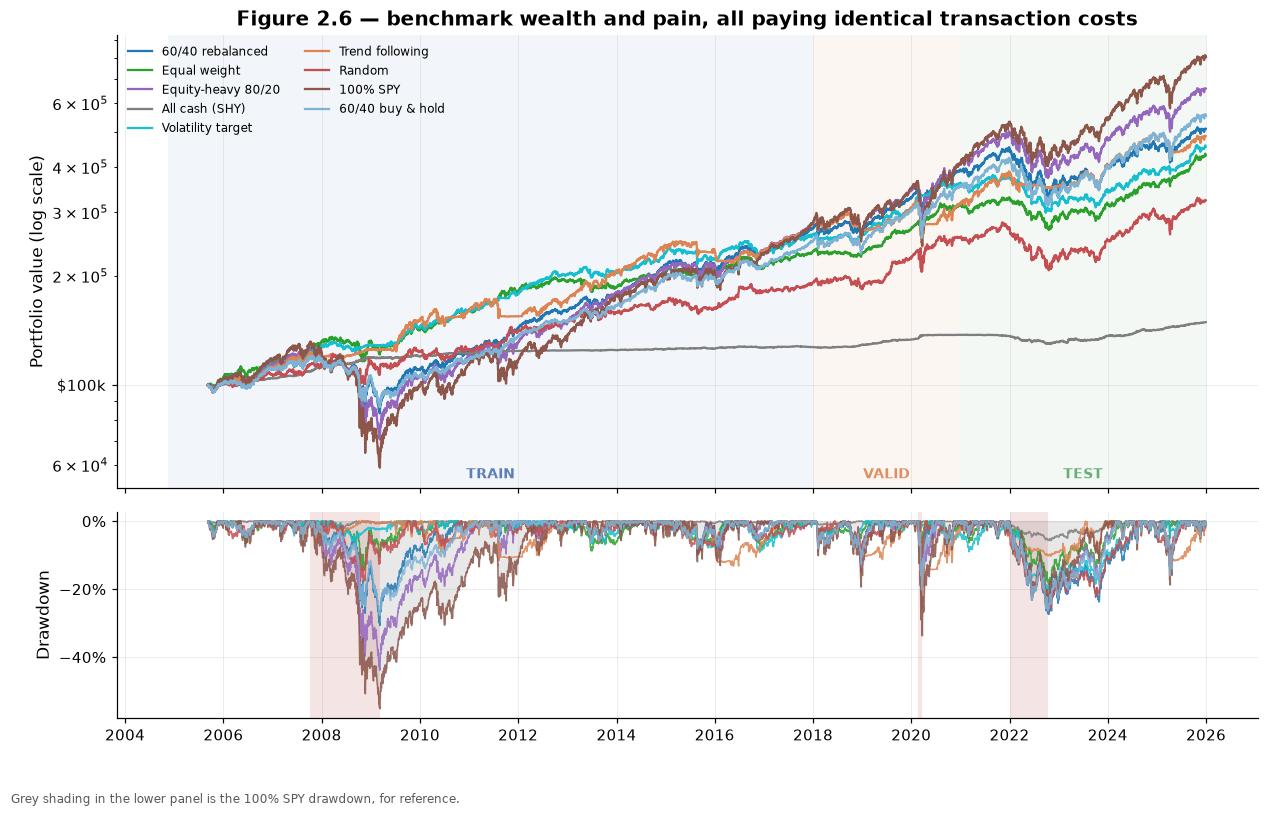

In [16]:
# Figure 2.6 -- what the benchmarks actually did.
fig, (ax, ax2) = plt.subplots(2, 1, figsize=(11.5, 7), sharex=True,
                              gridspec_kw={"height_ratios": [2.2, 1]})

for name, (daily, _) in results.items():
    colour = plots.strategy_color(name)
    ax.plot(daily.index, daily["wealth"], lw=1.5, color=colour, label=name)
    ax2.plot(daily.index, -daily["drawdown"], lw=1.0, color=colour, alpha=0.85)

ax.set_yscale("log")
ax.set_ylabel("Portfolio value (log scale)")
ax.set_title("Figure 2.6 — benchmark wealth and pain, all paying identical transaction costs")
ax.legend(ncol=2, loc="upper left", fontsize=8)
plots.format_money_axis(ax)
plots.shade_splits(ax)

ax2.set_ylabel("Drawdown")
ax2.fill_between(results["100% SPY"][0].index, -results["100% SPY"][0]["drawdown"], 0,
                 color="0.75", alpha=0.35, zorder=0)
plots.format_pct_axis(ax2)
plots.annotate_crises(ax2, label=False)
plots.tidy_dates(ax2, interval=2)

plots.caption(fig, "Grey shading in the lower panel is the 100% SPY drawdown, for reference.")
fig.tight_layout()
plots.save_fig(fig, "02_06_benchmark_equity")
plt.show()

**What this shows.** All-equity wins on wealth and loses badly on pain — a 55%
drawdown in 2008 that takes years to recover — while the static diversified
sleeves give up growth for shallower holes.

The interesting lines are the two adaptive rules. Trend following steps out of
equities before the worst of 2008 and keeps its drawdown to a fraction of the
static portfolios', and volatility targeting does something similar with a
different signal. **These are not straw men.** The agent is not being asked to
beat buy-and-hold; it is being asked to beat rules that already do the obvious
thing with the information in its own observation vector.

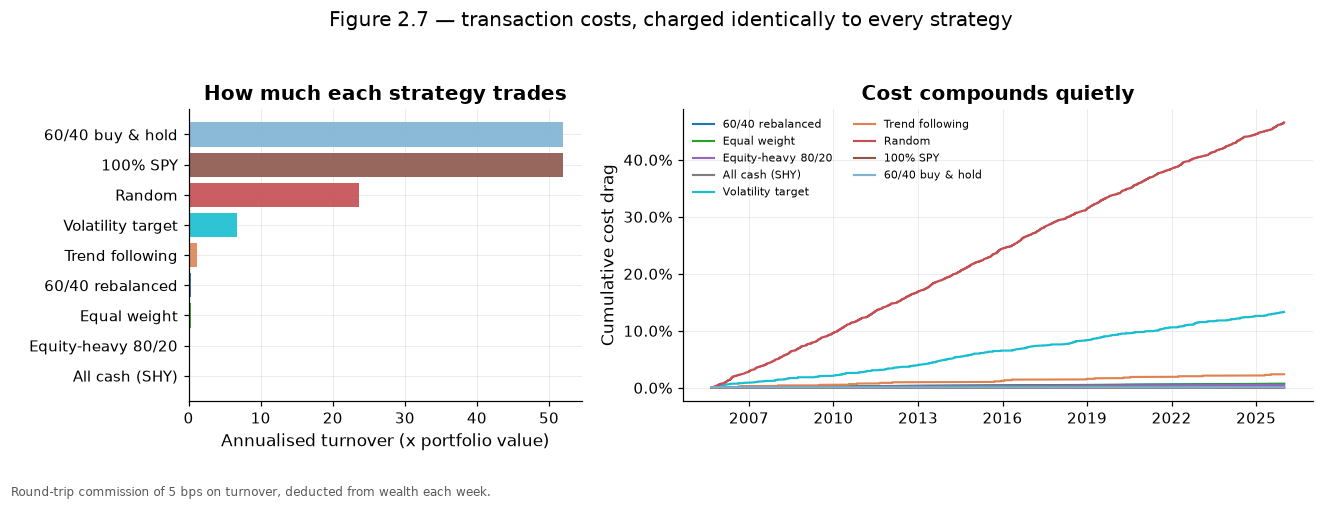

In [17]:
# Figure 2.7 -- what trading costs each strategy over the full sample.
fig, (ax, ax2) = plt.subplots(1, 2, figsize=(12, 4), gridspec_kw={"width_ratios": [1, 1.6]})

names = list(results)
turnovers = [results[n][1]["mean_turnover"] * 52 for n in names]
costs = [results[n][1]["total_cost_fraction"] for n in names]
order = np.argsort(turnovers)

ax.barh([names[i] for i in order], [turnovers[i] for i in order],
        color=[plots.strategy_color(names[i]) for i in order], alpha=0.9)
ax.set_xlabel("Annualised turnover (x portfolio value)")
ax.set_title("How much each strategy trades")

for name in names:
    daily, summary = results[name]
    cum_cost = summary["decisions"]["cost_fraction"].cumsum().reindex(daily.index).ffill().fillna(0.0)
    ax2.plot(daily.index, cum_cost, lw=1.4, color=plots.strategy_color(name), label=name)
ax2.set_ylabel("Cumulative cost drag")
ax2.set_title("Cost compounds quietly")
plots.format_pct_axis(ax2, decimals=1)
plots.tidy_dates(ax2, interval=3)
ax2.legend(ncol=2, fontsize=7, loc="upper left")

fig.suptitle("Figure 2.7 — transaction costs, charged identically to every strategy", y=1.04)
plots.caption(fig, f"Round-trip commission of {CFG.env.transaction_cost_bps:.0f} bps on turnover, deducted from wealth each week.")
fig.tight_layout()
plots.save_fig(fig, "02_07_turnover_cost")
plt.show()

**What this shows.** The random policy burns roughly a percentage point a year in
fees for no reason at all, while buy-and-hold pays once and never again. This is
why the random floor is a genuinely low bar — and why an agent that trades a lot
must earn back its costs before it earns anything else.

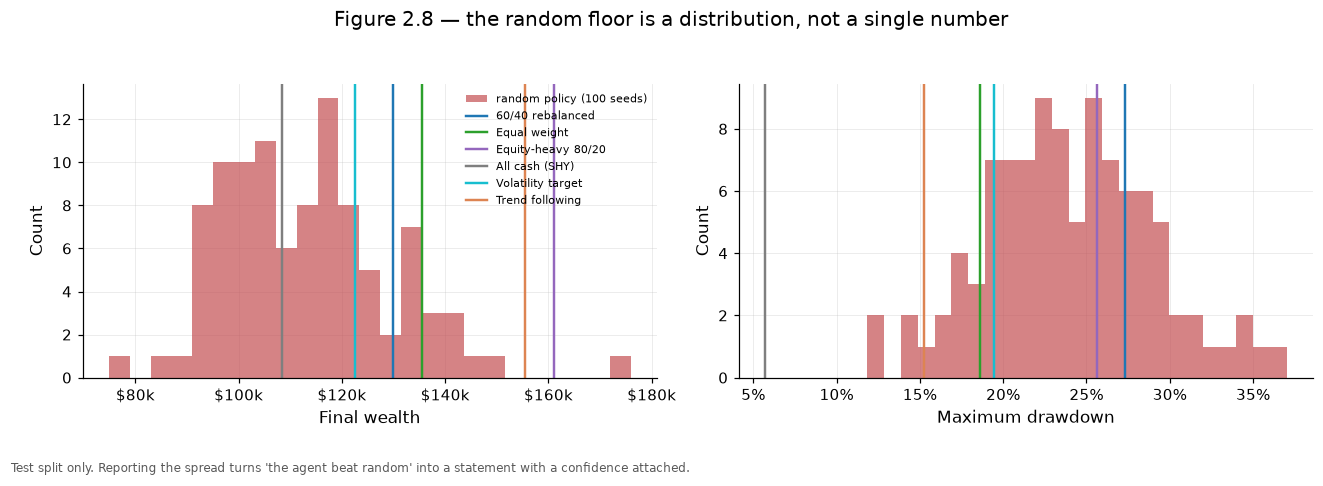

Random policy, 100 seeds -- final wealth $113,179 +/- $16,286   (min $74,854, max $175,900)


In [18]:
# Figure 2.8 -- the random-policy floor, across 100 seeds.
floor = benchmarks.average_random_floor(test, n_seeds=100)
rf_test = ds.risk_free.reindex(test.prices.index)

static_test = {
    n: env.run_policy(test, benchmarks.constant_action(a))
    for n, a in benchmarks.STATIC_BENCHMARKS.items()
}
static_test["Volatility target"] = env.run_policy(test, benchmarks.volatility_target_policy(ds))
static_test["Trend following"] = env.run_policy(test, benchmarks.trend_following_policy(ds))

fig, axes = plt.subplots(1, 2, figsize=(12, 3.8))
for ax, column, label in zip(axes, ["Final wealth", "Max drawdown"], ["Final wealth", "Maximum drawdown"]):
    ax.hist(floor[column], bins=25, color="#c44e52", alpha=0.7, label="random policy (100 seeds)")
    for name, (daily, summary) in static_test.items():
        row = metrics.performance_summary(daily, summary=summary, risk_free=rf_test)
        ax.axvline(row[column], color=plots.strategy_color(name), lw=1.6, label=name)
    ax.set_xlabel(label)
    ax.set_ylabel("Count")
    if column == "Final wealth":
        plots.format_money_axis(ax, axis="x")
    else:
        plots.format_pct_axis(ax, axis="x")

axes[0].legend(fontsize=7, loc="upper right")
fig.suptitle("Figure 2.8 — the random floor is a distribution, not a single number", y=1.04)
plots.caption(fig, "Test split only. Reporting the spread turns 'the agent beat random' into a statement with a confidence attached.")
fig.tight_layout()
plots.save_fig(fig, "02_08_random_floor")
plt.show()

print(f"Random policy, 100 seeds -- final wealth ${floor['Final wealth'].mean():,.0f} "
      f"+/- ${floor['Final wealth'].std():,.0f}   (min ${floor['Final wealth'].min():,.0f}, "
      f"max ${floor['Final wealth'].max():,.0f})")

**What this shows.** A single lucky random seed can land near a real strategy, so
comparing against one random run would be an anecdote. The spread is what makes
the comparison a claim: the agent will have to clear the *upper tail* of this
distribution, not its mean.

### 7.1 The bar to beat

The table below is the target. The agent's numbers, computed with exactly this
code on exactly this split, go next to it in notebook 05.

In [19]:
test_results = {
    name: (env.run_policy(test, benchmarks.constant_action(a)))
    for name, a in benchmarks.STATIC_BENCHMARKS.items()
}
test_results["Volatility target"] = env.run_policy(test, benchmarks.volatility_target_policy(ds))
test_results["Trend following"] = env.run_policy(test, benchmarks.trend_following_policy(ds))
test_results["Random"] = env.run_policy(test, benchmarks.random_policy(0))
for name, weights in benchmarks.HOLD_BENCHMARKS.items():
    test_results[name] = benchmarks.buy_and_hold(test, weights)

card = metrics.scorecard(
    test_results, risk_free=rf_test, benchmark_key="60/40 rebalanced",
    columns=metrics.SCORECARD_COLUMNS,
)
card.to_csv(config.ARTIFACTS_RESULTS / "02_benchmark_scorecard_test.csv")

display(
    plots.style_scorecard(
        card,
        higher_is_better=metrics.HIGHER_IS_BETTER,
        lower_is_better=metrics.LOWER_IS_BETTER,
        fmt=metrics.SCORECARD_FORMATS,
        caption_text="Table 2.5 — benchmark performance on the held-out test split (2021-2025)",
    )
)

,Final wealth,Total return,CAGR,Volatility,Sharpe,Sortino,Max drawdown,Calmar,Longest drawdown (days),VaR 95% (daily),CVaR 95% (daily),Hit rate,Skew,Excess kurtosis,Ann. turnover,Total cost
60/40 rebalanced,"$129,889",30.2%,5.45%,12.44%,0.230,0.699,27.33%,0.199,665,1.27%,1.77%,53.3%,0.21,5.86,0.47,0.23%
Equal weight,"$135,561",35.9%,6.35%,8.24%,0.399,1.161,18.61%,0.341,567,0.81%,1.10%,54.8%,0.25,3.61,0.44,0.22%
Equity-heavy 80/20,"$161,035",61.3%,10.09%,14.25%,0.520,1.080,25.60%,0.394,540,1.36%,2.06%,52.9%,0.31,8.50,0.38,0.19%
All cash (SHY),"$108,397",8.4%,1.63%,1.95%,-0.812,1.302,5.71%,0.286,711,0.18%,0.27%,48.6%,0.66,6.19,0.00,0.00%
Volatility target,"$122,444",27.3%,4.96%,8.41%,0.236,0.900,19.48%,0.255,713,0.84%,1.16%,54.0%,0.20,3.58,7.73,3.85%
Trend following,"$155,503",56.4%,9.40%,11.30%,0.567,1.247,15.25%,0.616,389,1.10%,1.65%,51.7%,0.69,18.91,1.13,0.56%
Random,"$99,493",11.6%,2.23%,10.32%,-0.046,0.372,27.25%,0.082,943,1.10%,1.50%,51.7%,-0.07,4.51,23.05,11.47%
100% SPY,"$197,887",98.1%,14.71%,17.10%,0.700,1.290,24.50%,0.601,488,1.66%,2.48%,54.7%,0.29,9.15,0.20,0.10%
60/40 buy & hold,"$144,586",44.7%,7.71%,13.46%,0.380,0.891,26.99%,0.285,612,1.31%,1.93%,52.8%,0.35,9.29,0.20,0.10%


In [20]:
# The same comparison across all three splits, to show how unstable the ranking is.
rows = []
for split in ("train", "valid", "test"):
    part = ds.split(split)
    rf_part = ds.risk_free.reindex(part.prices.index)
    for name, action in benchmarks.STATIC_BENCHMARKS.items():
        daily, summary = env.run_policy(part, benchmarks.constant_action(action))
        row = metrics.performance_summary(daily, summary=summary, risk_free=rf_part, name=name)
        rows.append({"Split": split, "Strategy": name, "Sharpe": row["Sharpe"],
                     "CAGR": row["CAGR"], "Max drawdown": row["Max drawdown"]})

by_split = pd.DataFrame(rows).pivot(index="Strategy", columns="Split", values="Sharpe")
by_split = by_split[["train", "valid", "test"]]
display(
    by_split.style.format("{:.3f}")
    .background_gradient(cmap="RdYlGn", axis=None)
    .set_caption("Table 2.6 — Sharpe ratio by split: the best static allocation is not the same in every regime")
)

Split,train,valid,test
Strategy,,,
60/40 rebalanced,0.732,0.967,0.230
All cash (SHY),0.645,1.073,-0.812
Equal weight,0.856,1.226,0.399
Equity-heavy 80/20,0.582,0.755,0.520


**Why this table matters.** The static allocation with the best Sharpe ratio
changes between splits. That instability is precisely the opportunity a
*dynamic* policy is supposed to exploit — and equally the reason a single-split
result would be untrustworthy. It is also a warning: a fixed rule that happens to
suit 2021–2025 is not evidence of skill.

## 8 Outputs written

In [21]:
figures = sorted(config.ARTIFACTS_FIGURES.glob("02_*.png"))
for path in figures:
    print(f"  {path.relative_to(config.PROJECT_ROOT)}  ({path.stat().st_size / 1024:,.0f} KB)")
print(f"  {(config.ARTIFACTS_RESULTS / '02_benchmark_scorecard_test.csv').relative_to(config.PROJECT_ROOT)}")
print(f"\n{len(figures)} figures written.")

  artifacts\figures\02_01_mdp_loop.png  (68 KB)
  artifacts\figures\02_02_weight_drift.png  (251 KB)
  artifacts\figures\02_03_golden_test.png  (208 KB)
  artifacts\figures\02_04_reward_decomposition.png  (111 KB)
  artifacts\figures\02_05_episode_sampler.png  (62 KB)
  artifacts\figures\02_06_benchmark_equity.png  (375 KB)
  artifacts\figures\02_07_turnover_cost.png  (116 KB)
  artifacts\figures\02_08_random_floor.png  (69 KB)
  artifacts\results\02_benchmark_scorecard_test.csv

8 figures written.


## Key takeaways

1. **The environment is verified, not assumed.** Two independently derived wealth
   paths — a closed-form price ratio and a share-based buy-and-hold — are
   reproduced to within $10^{-12}$ relative error, so the cost model, the weight
   drift and the daily compounding are all correct. Both checks are locked in as
   automated tests.
2. **Turnover is measured against drifted weights.** Holding a "static" 60/40 is
   not free; it costs a real, measurable amount every week. Any backtest that
   reports zero turnover for a constant allocation is wrong.
3. **The reward is additive in log wealth.** With the penalties off, total episode
   reward is exactly $\log(W_T/W_0)$, so the RL objective and the investment
   objective coincide instead of merely correlating.
4. **The penalties are calibrated, not decorative.** Each is a modest fraction of
   the growth term; an earlier $\lambda_1$ that was 250× larger would have taught
   the agent to sit in cash and never learn anything.
5. **The benchmarks are hard and honest.** They pay identical costs at an
   identical frequency, they include two adaptive rivals that react to signals
   already present in the agent's own observation vector, and the random floor is
   reported as a distribution rather than a single lucky run. A degenerate
   "risk parity" benchmark was identified and discarded rather than kept because
   it flattered the comparison.
6. **No single static allocation wins everywhere** (Table 2.6) — which is both the
   motivation for a dynamic policy and the reason results are reported on a
   held-out split the agent never touched.

Next: **notebook 03** trains the DQN against exactly this environment.